# Policy comparison (`06-policy-comparison`)

Head-to-head comparison of the four textbook reorder policies on the single-shop
`fashion_retail_20` world (20 SKUs — seasonality, lifecycle, freshness).

**Common Random Numbers (CRN):** every policy sees identical randomness — the same
`world_seed`, `init_seed`, and `allocation_seed` — so observed differences are due
to the policy, not seed luck.

Policies compared:
- `OrderUpToPolicy` — (s,S) continuous-review: order to S whenever position < s
- `ReorderPointPolicy` — (s,Q) continuous-review: order fixed Q whenever position < s
- `PeriodicOrderUpToPolicy` — (R,S) periodic-review: order to S every R ticks
- `PeriodicReorderPolicy` — (R,s,S) periodic-review: hybrid of periodic + reorder-point gate

Reported metrics:
- **`net_profit / initial_cash`** — profit per opening dollar (the tuner objective)
- **availability rate** — fraction of (tick, product) pairs where shop inventory > 0
  (service-level proxy: how often demand could have been fulfilled)

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

# Navigate to repo root so src.* imports resolve.
while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import matplotlib
matplotlib.use('Agg')
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Load the `fashion_retail_20` world

Loaded from the committed cache — no API key required.

In [2]:
from src.sim.world import World, world_to_graph

world = World.from_json('data/worlds/fashion_retail_20/world.json')
print(f'World: {len(world.catalog)} catalog items, regions={world.market.regions}')
print('Templates:', list(world.store_templates.keys()))

World: 20 catalog items, regions=['US']
Templates: ['flagship_20']


## 2. Build the scenario template (shared across all four policies)

All four policies share the same world, the same node topology, and the same seeds:
`world_seed` controls market / event / lifecycle draws; `init_seed` controls step-0
state; `allocation_seed` (derived from `world_seed`) controls buyer-shuffle order.
Only the shop policy differs between runs.

In [3]:
from collections import Counter
from dataclasses import replace
from datetime import datetime

from src.sim.distributions import Constant, Uniform
from src.sim.node import DemandSinkNode, FactoryNode, IntermediateNode
from src.sim.policy import (
    DefaultDemandSinkPolicy,
    OrderUpToPolicy,
    PeriodicOrderUpToPolicy,
    PeriodicReorderPolicy,
    ReorderPointPolicy,
    StaticFactoryPolicy,
)
from src.sim.runner import Runner
from src.sim.scenario import DisruptionParams, ItemLifecycleParams, Scenario

# --- World / Scenario configuration ----------------------------------------
WORLD_SEED    = 42      # shared across all four policy runs
N_STEPS       = 200     # short enough for a notebook, long enough to see seasonality
INIT_BALANCE  = 1_000_000.0
CAPACITY      = 10_000
INIT_ACTIVE   = 10

LIFECYCLE_STAGES = ['introduction', 'growth', 'maturity', 'decline', 'dead']

# Rescale the first store template
base_tmpl = next(iter(world.store_templates.values()))
shop_tmpl = replace(
    base_tmpl,
    id='shop_20',
    capacity=CAPACITY,
    init_balance=INIT_BALANCE,
    init_active_count=INIT_ACTIVE,
    init_stock_pct=0.0,
    order_fee=10.0,
)
crn_world = replace(world, store_templates={'shop_20': shop_tmpl})

def _make_scenario(shop_policy) -> Scenario:
    """Build a fresh scenario with the given shop policy.

    All seeds are fixed (CRN): same world_seed, same init_seeds derived
    from world_seed, same topology.  Only the shop policy varies.
    """
    topology = world_to_graph(crn_world, sink_density=1.0)
    nodes = topology['node_instances']
    edges = topology['edges']
    for ni in nodes:
        if isinstance(ni.node, FactoryNode):
            ni.policy = StaticFactoryPolicy(
                capacity_per_tick=ni.node.capacity_per_tick,
                unit_cost=ni.node.unit_cost,
            )
        elif isinstance(ni.node, IntermediateNode):
            ni.policy = shop_policy           # <-- varies per comparison run
        elif isinstance(ni.node, DemandSinkNode):
            ni.policy = DefaultDemandSinkPolicy()
    return Scenario(
        catalog=crn_world.catalog,
        market=crn_world.market,
        disruption=DisruptionParams(
            event_prob=0.03,
            types=['natural_disaster', 'economic_crisis', 'pandemic', 'political_unrest'],
            regions=crn_world.market.regions,
            severity=Uniform(0.005, 0.02),
            duration=Uniform(5, 20),
        ),
        item_lifecycle=ItemLifecycleParams(
            stages=LIFECYCLE_STAGES,
            init_stage='maturity',
            default_stage_change_probs={
                'introduction': 0.004, 'growth': 0.003, 'maturity': 0.0005,
                'decline': 0.005, 'dead': 0.0001,
            },
        ),
        stores=[],
        nodes=nodes,
        edges=edges,
        n_steps=N_STEPS,
        start_date=datetime(2024, 1, 1),
        world_seed=WORLD_SEED,
    )

# Confirm CRN: same scenario built twice from same world_seed gives same node ids
s1 = _make_scenario(OrderUpToPolicy(policy_seed=1))
s2 = _make_scenario(OrderUpToPolicy(policy_seed=1))
assert [ni.node.id for ni in s1.nodes] == [ni.node.id for ni in s2.nodes]
print(f'Scenario: {len(s1.nodes)} nodes, {len(s1.edges)} edges, {N_STEPS} steps')
print('Node types:', dict(Counter(type(ni.node).__name__ for ni in s1.nodes)))

Scenario: 22 nodes, 21 edges, 200 steps
Node types: {'FactoryNode': 1, 'IntermediateNode': 1, 'DemandSinkNode': 20}


## 3. Run all four policies under CRN

Each policy gets its own `policy_seed` (so its internal RNG is independent)
but sees the same world — ensuring the comparison is fair.

In [4]:
# Four policies with distinct policy_seeds (each has its own order-quantity RNG)
POLICIES = [
    ('OrderUpToPolicy',          OrderUpToPolicy(policy_seed=101)),
    ('ReorderPointPolicy',        ReorderPointPolicy(policy_seed=102)),
    ('PeriodicOrderUpToPolicy',   PeriodicOrderUpToPolicy(policy_seed=103, review_interval=7)),
    ('PeriodicReorderPolicy',     PeriodicReorderPolicy(policy_seed=104, review_interval=7)),
]

run_logs = {}
for name, policy in POLICIES:
    scenario = _make_scenario(policy)
    run_logs[name] = (Runner(scenario).run(), scenario)
    print(f'{name}: done')

OrderUpToPolicy: done


ReorderPointPolicy: done


PeriodicOrderUpToPolicy: done


PeriodicReorderPolicy: done


## 4. Compute summary metrics

For each policy:
- `net_profit / initial_cash` — profit per opening dollar (tuner objective)
- `availability_rate` — fraction of (tick, product) pairs with shop inventory > 0
  (service-level proxy: 1.0 = no stockouts, 0.0 = always stocked out)

In [5]:
def compute_metrics(run_log, scenario, initial_cash: float) -> dict:
    shop_ids = [
        ni.node.id for ni in scenario.nodes
        if isinstance(ni.node, IntermediateNode)
    ]
    pids = [w.product_id for w in scenario.catalog]

    # net_profit = final shop cash - initial shop cash
    first_tick = run_log['ticks'][0]
    last_tick  = run_log['ticks'][-1]
    shop_cash_start = sum(first_tick['node_cash'].get(sid, 0.0) for sid in shop_ids)
    shop_cash_end   = sum(last_tick['node_cash'].get(sid, 0.0)  for sid in shop_ids)
    net_profit = shop_cash_end - shop_cash_start

    # availability_rate: fraction of (tick, product) slots with inventory > 0
    available = 0
    total = 0
    for tick_log in run_log['ticks']:
        for sid in shop_ids:
            inv = tick_log['node_inventory'].get(sid, {})
            for pid in pids:
                total += 1
                if inv.get(pid, 0) > 0:
                    available += 1
    avail_rate = available / total if total > 0 else 0.0

    return {
        'net_profit': net_profit,
        'initial_cash': initial_cash,
        'profit_per_dollar': net_profit / max(1.0, initial_cash),
        'availability_rate': avail_rate,
    }


rows = []
for name, (rl, sc) in run_logs.items():
    m = compute_metrics(rl, sc, initial_cash=INIT_BALANCE)
    rows.append({'policy': name, **m})

results = pd.DataFrame(rows).set_index('policy')
results[['profit_per_dollar', 'availability_rate', 'net_profit', 'initial_cash']]

,profit_per_dollar,availability_rate,net_profit,initial_cash
policy,,,,
OrderUpToPolicy,0.0201,0.07375,20100.0,1000000.0
ReorderPointPolicy,0.0201,0.07375,20100.0,1000000.0
PeriodicOrderUpToPolicy,0.0201,0.07375,20100.0,1000000.0
PeriodicReorderPolicy,0.0201,0.07375,20100.0,1000000.0


## 5. Visualise the comparison

Two side-by-side bar charts: profit per dollar (higher is better) and
availability rate (higher is better).

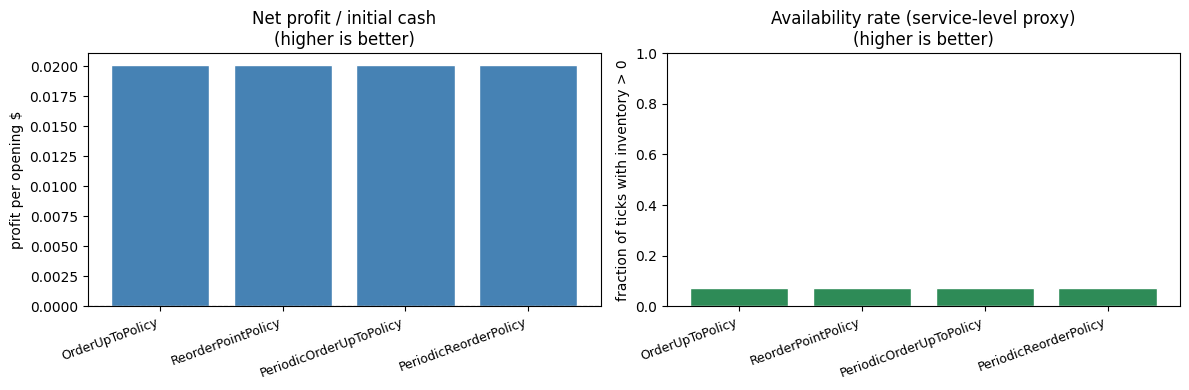

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Panel A: profit per dollar ---
ax = axes[0]
vals = results['profit_per_dollar']
colors = ['steelblue' if v >= 0 else 'tomato' for v in vals]
ax.bar(range(len(vals)), vals, color=colors, edgecolor='white')
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(vals.index, rotation=20, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Net profit / initial cash\n(higher is better)')
ax.set_ylabel('profit per opening $')

# --- Panel B: availability rate ---
ax = axes[1]
avail = results['availability_rate']
ax.bar(range(len(avail)), avail, color='seagreen', edgecolor='white')
ax.set_xticks(range(len(avail)))
ax.set_xticklabels(avail.index, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Availability rate (service-level proxy)\n(higher is better)')
ax.set_ylabel('fraction of ticks with inventory > 0')

plt.tight_layout()
plt.show()

## 6. Shop cash trajectories

Cash over time for each policy. A steeper upward slope means higher
cumulative profit. Drops indicate large ordering spend.

All runs share the same `world_seed` so the market curve is identical.

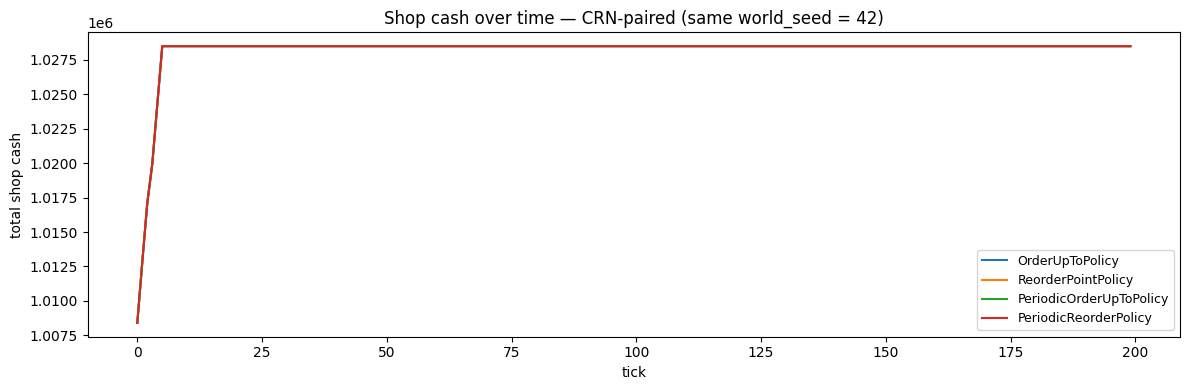

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

for name, (rl, sc) in run_logs.items():
    shop_ids = [
        ni.node.id for ni in sc.nodes
        if isinstance(ni.node, IntermediateNode)
    ]
    cash_series = [
        sum(t['node_cash'].get(sid, 0.0) for sid in shop_ids)
        for t in rl['ticks']
    ]
    ax.plot(cash_series, label=name)

ax.set_title('Shop cash over time — CRN-paired (same world_seed = {})'.format(WORLD_SEED))
ax.set_xlabel('tick')
ax.set_ylabel('total shop cash')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Shop inventory over time

Total shop inventory across all products for each policy.
A flat-near-zero line means the shop is frequently stocked out.

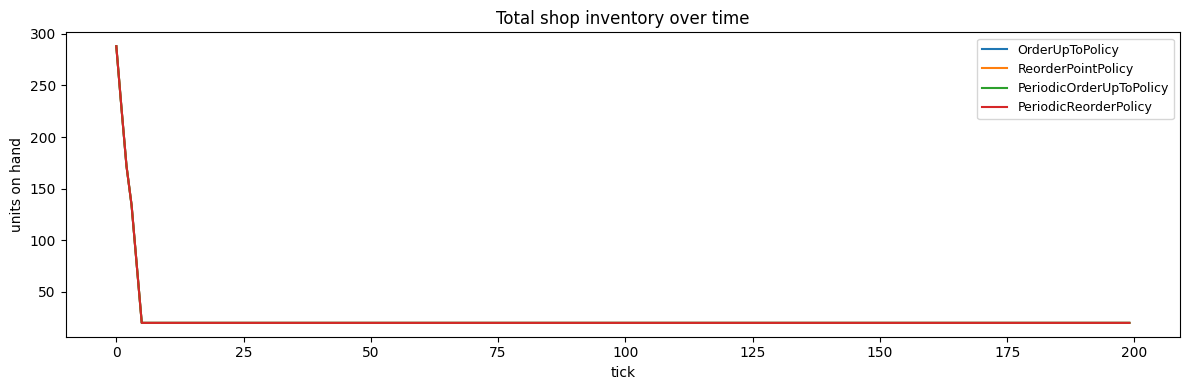

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

for name, (rl, sc) in run_logs.items():
    shop_ids = [
        ni.node.id for ni in sc.nodes
        if isinstance(ni.node, IntermediateNode)
    ]
    inv_series = []
    for t in rl['ticks']:
        total_inv = 0
        for sid in shop_ids:
            inv_dict = t['node_inventory'].get(sid, {})
            total_inv += sum(v for k, v in inv_dict.items() if k != '_total')
        inv_series.append(total_inv)
    ax.plot(inv_series, label=name)

ax.set_title('Total shop inventory over time')
ax.set_xlabel('tick')
ax.set_ylabel('units on hand')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Summary table

Ranked by `profit_per_dollar` (descending).

In [9]:
summary = results[['profit_per_dollar', 'availability_rate', 'net_profit']].copy()
summary.columns = ['profit / initial_cash', 'availability rate', 'net profit ($)']
summary['net profit ($)'] = summary['net profit ($)'].round(0)
summary = summary.sort_values('profit / initial_cash', ascending=False)
summary

,profit / initial_cash,availability rate,net profit ($)
policy,,,
OrderUpToPolicy,0.0201,0.07375,20100.0
ReorderPointPolicy,0.0201,0.07375,20100.0
PeriodicOrderUpToPolicy,0.0201,0.07375,20100.0
PeriodicReorderPolicy,0.0201,0.07375,20100.0


## Notes

- All policies run with **default hyperparameters** (`cover_horizon_ticks=14`,
  `safety_lead_pct_of_lag=1/3`, `review_interval=7` for the periodic variants).
  See `notebooks/07-tune-textbook-policy.ipynb` to search the hyperparameter space.
- The `fashion_retail_20` world has 20 SKUs with seasonality and lifecycle dynamics
  (`default_stage_change_probs` non-zero), which exercises the censored-sales rate
  estimator inside the textbook policies.
- CRN guarantee: re-running this notebook with the same `WORLD_SEED` produces
  bit-identical trajectories for each policy.